### Problem Statement : Socioeconomic Group Discovery using Census Data

### Aim:
The aim of this project is to identify hidden socioeconomic groups within the adult population using unsupervised learning techniques on census data. By analyzing demographic and work-related features, the project seeks to uncover meaningful patterns that can support better policy-making and targeted interventions.

### Objective :

*  To preprocess the dataset by handling missing values, encoding categorical variables, and scaling numerical features.
*  To perform exploratory data analysis to understand patterns, distributions, and relationships among variables.
*  To apply clustering algorithms such as K-Means and Agglomerative Clustering to identify hidden groups in the data.
*   To analyze and interpret the resulting clusters in order to derive meaningful insights for socioeconomic segmentation and policy recommendations.



### Libraries

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

### Reading Dataset

In [68]:
filepath = '/content/drive/MyDrive/ICT DSA/Data Sets/adult_dataset.csv'
data = pd.read_csv(filepath)

In [69]:
data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


### 1. Data Preprocessing & EDA

In [70]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [71]:
data.shape

(48842, 15)

In [72]:
#before cleaning unique values in income
data['income'].unique()

array(['<=50K', '>50K', '<=50K.', '>50K.'], dtype=object)

In [73]:
#The income column had small differences in values like “<=50K” and “<=50K.
#These were cleaned by removing the extra dot
data['income'] = data['income'].str.replace('.', '', regex=False)

In [74]:
#after cleaning unique values in income
data['income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [75]:
#To check duplicated rows and columns
#before removing duplicate rows
data.duplicated().sum()

np.int64(25)

In [76]:
data.T.duplicated().sum()

np.int64(0)

In [77]:
#To remove duplicated rows
data = data.drop_duplicates()

In [78]:
#after removing duplicates
data.duplicated().sum()

np.int64(0)

In [79]:
#To check '?' values in the data
#before replacing '?'
(data == '?').sum()

,0
age,0
workclass,1763
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1758
relationship,0
race,0
sex,0


In [80]:
#Replace '?' with NaN
data.replace('?', np.nan, inplace=True)


In [81]:
#after replacing '?'
(data == '?').sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [82]:
#to check for missing values
#before handling missing values
data.isnull().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [83]:
#To check the Missing values in percentage
missing_percent = data.isna().sum()/len(data)*100
missing_percent.sort_values(ascending=False)

,0
workclass,10.498392
occupation,10.477907
native-country,6.678002
hours-per-week,5.002356
age,5.002356
fnlwgt,0.000000
education,0.000000
marital-status,0.000000
education-num,0.000000
relationship,0.000000


In [84]:
# Separate numerical and categorical columns
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

In [85]:
print("The numerical columns are: ")
print(num_cols)
print('\n')
print("The categorical columns are: ")
print(cat_cols)

The numerical columns are: 
Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')


The categorical columns are: 
Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')


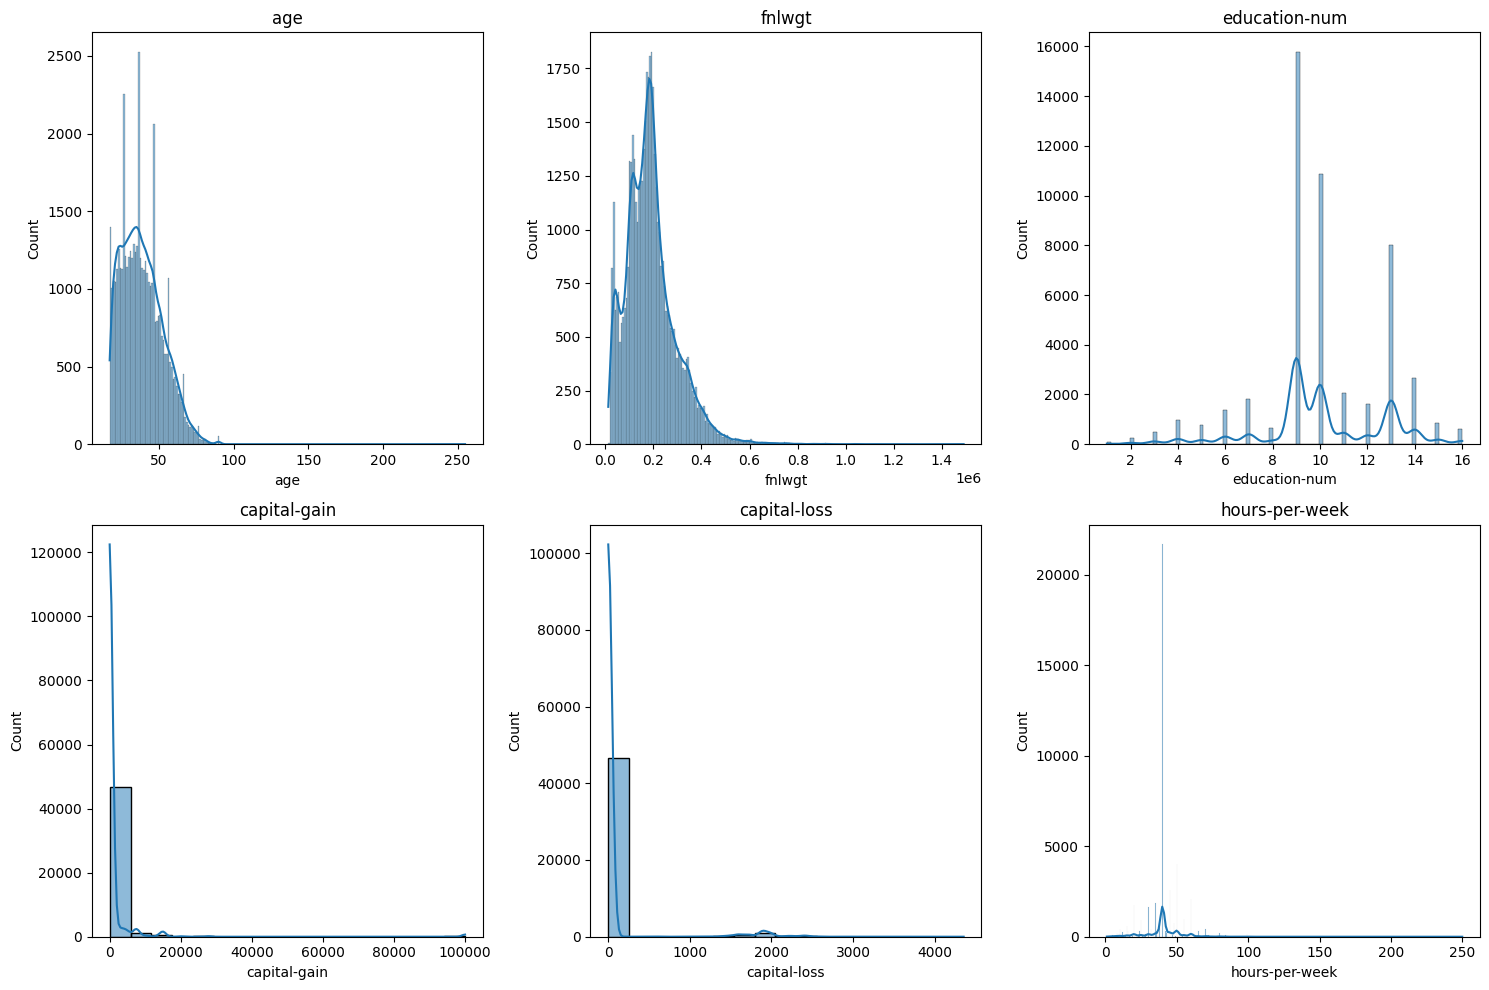

In [86]:
# Plotting Histogram for Numerical Columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

In [87]:
#Replacing missing values in the numerical column with median
#since all the plots are skewed.
for col in num_cols:
    data[col].fillna(data[col].median(), inplace=True)

/tmp/ipykernel_9661/97140926.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)


In [88]:
#Replacing  missing values in the categorical column with mode
for col in cat_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

/tmp/ipykernel_9661/991482294.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [89]:
#after handling missing values
data.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


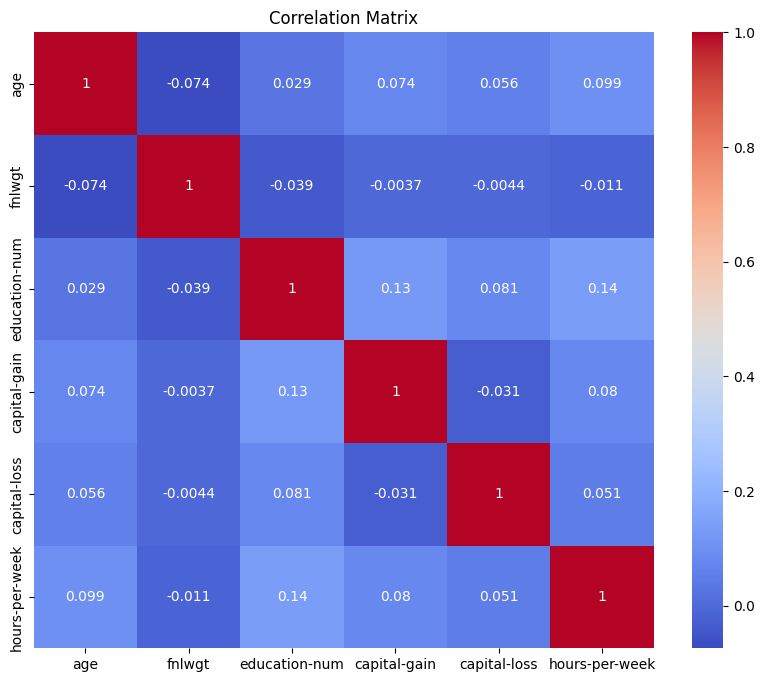

In [90]:
# Correlation (before encoding)
plt.figure(figsize=(10, 8))
sns.heatmap(data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

#### Outlier Handling

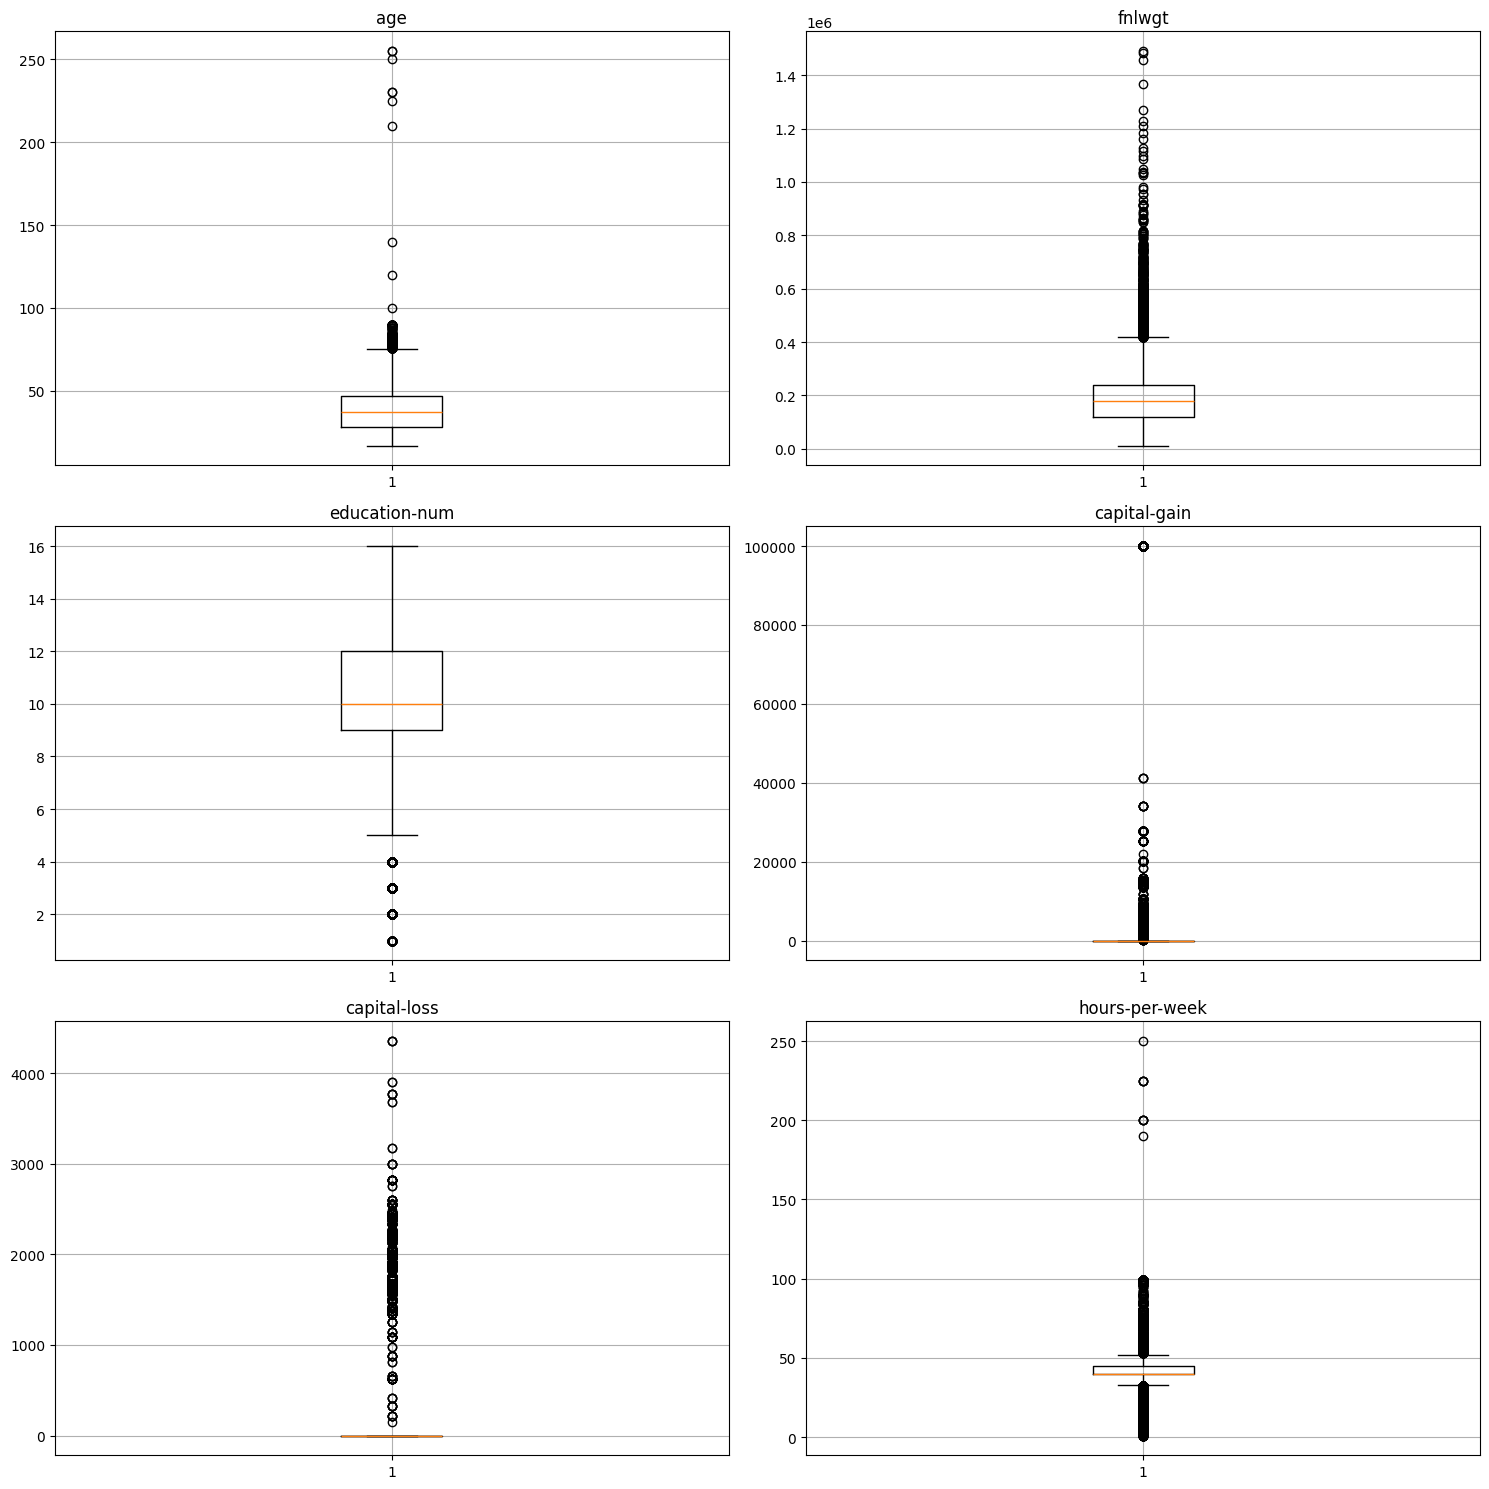

In [91]:
#To check for outliers using box plot
plt.figure(figsize=(15,15))
for i,col in enumerate(num_cols, 1):
  plt.subplot(3,2,i)
  plt.boxplot(data[col])
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

In [92]:
Q1 = data[num_cols].quantile(0.25)
Q3 = data[num_cols].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + (1.5 * IQR)
lower_limit = Q1 - (1.5 * IQR)

outliers = ((data[num_cols]>upper_limit) |
            (data[num_cols]< lower_limit)).any(axis = 1)


print(outliers)


0         True
1         True
2        False
3        False
4        False
         ...  
48837    False
48838    False
48839    False
48840     True
48841     True
Length: 48817, dtype: bool


In [93]:
outliers_df = data[outliers]
outliers_df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
6,49.0,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16.0,Jamaica,<=50K
8,31.0,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50.0,United-States,>50K
9,42.0,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40.0,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48825,64.0,Self-emp-not-inc,136405,HS-grad,9,Widowed,Farming-fishing,Not-in-family,White,Male,0,0,32.0,United-States,<=50K
48827,55.0,Private,224655,HS-grad,9,Separated,Priv-house-serv,Not-in-family,White,Female,0,0,32.0,United-States,<=50K
48833,31.0,Private,440129,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40.0,United-States,<=50K
48840,44.0,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40.0,United-States,<=50K


In [94]:
# to check % of outlier values
outlier_percent = len(outliers_df) * 100/len(data)
print("Percentage of outliers in the dataframe : ", outlier_percent)


Percentage of outliers in the dataframe :  40.44902390560665


In [95]:
#Since percentage of outliers is 40%, we clip it
data[num_cols] = data[num_cols].clip(lower_limit, upper_limit, axis = 1)

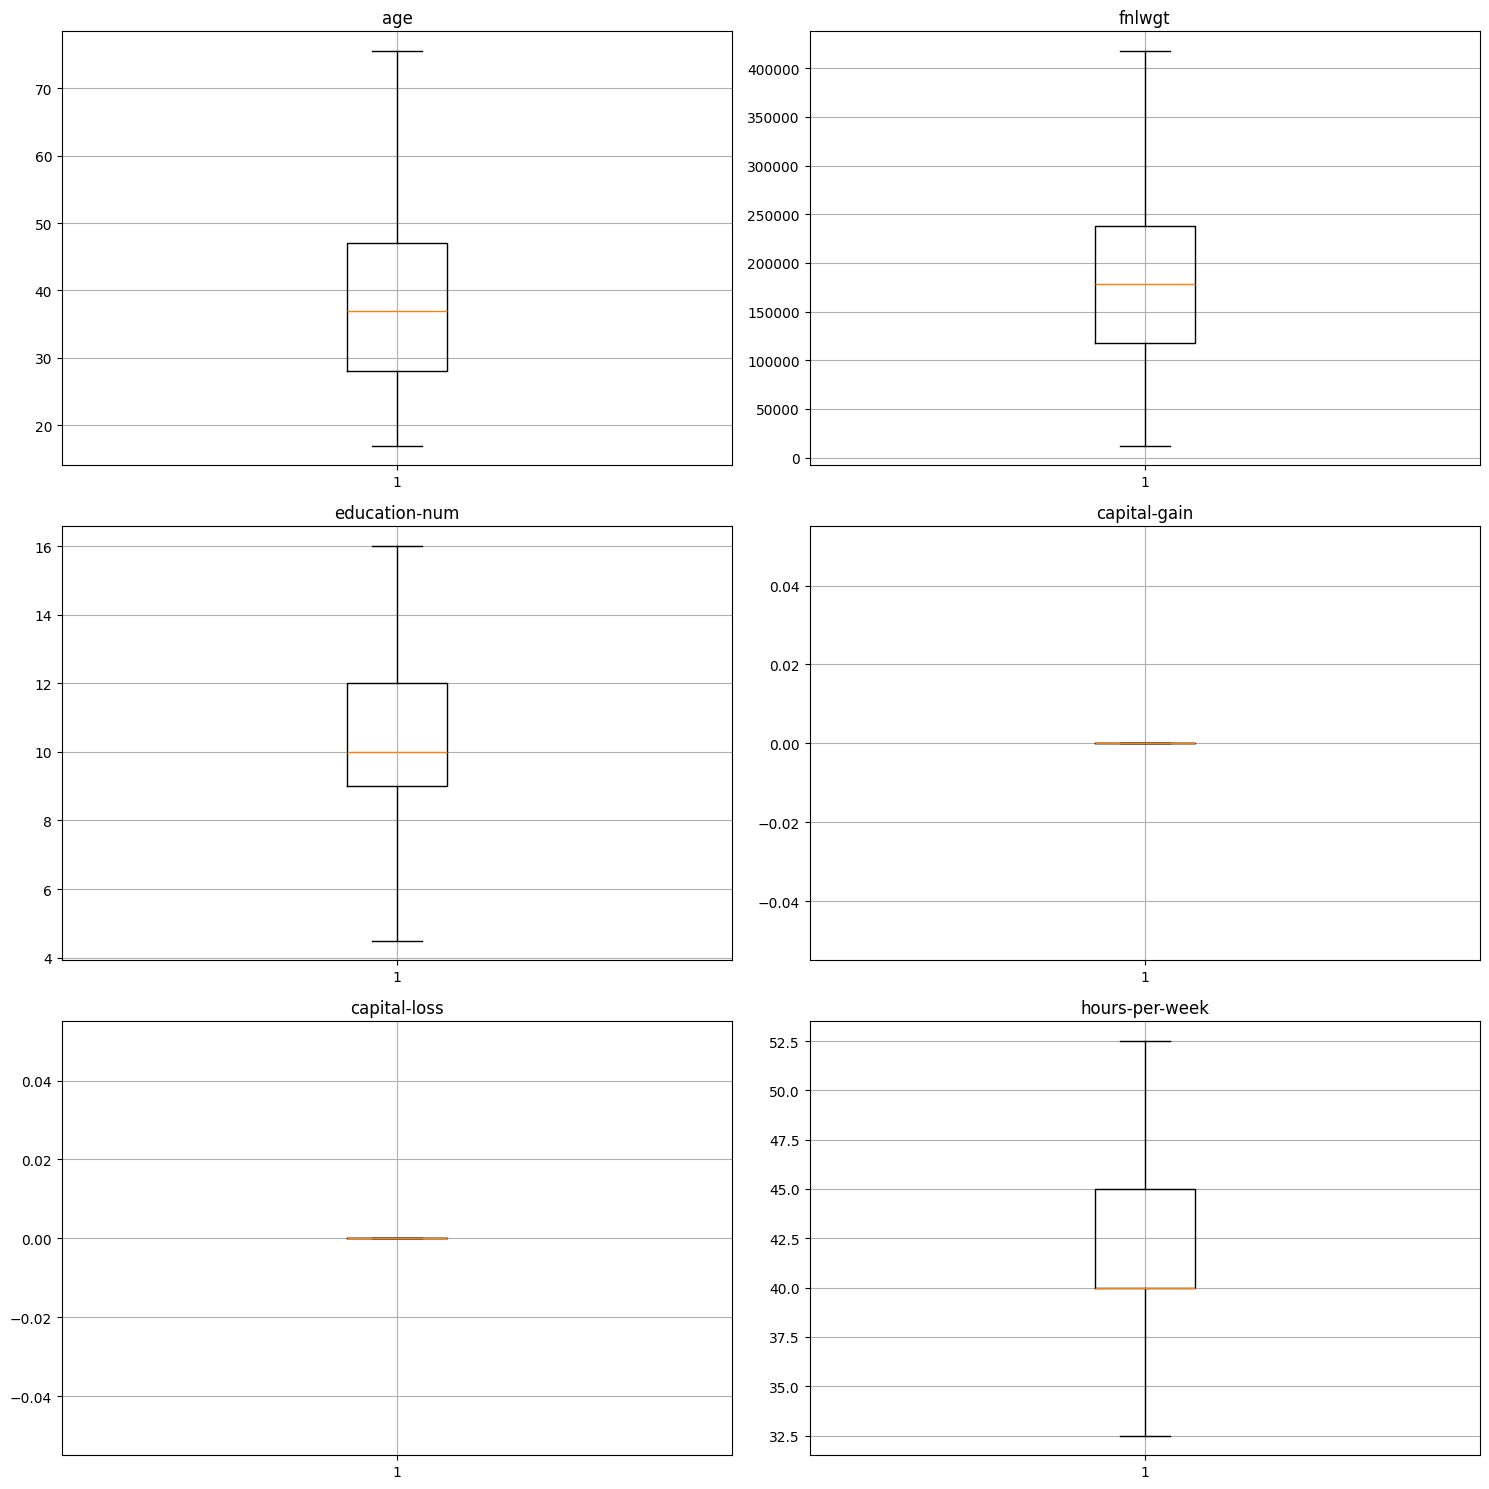

In [96]:
#after clipping the outliers
plt.figure(figsize=(15,15))
for i,col in enumerate(num_cols, 1):
  plt.subplot(3,2,i)
  plt.boxplot(data[col])
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

#### Column Removal and Feature Engineering

In [97]:
# We drop 'education' because 'education-num' is the numeric version of the same data.
# We drop 'fnlwgt' as it is a sampling weight and usually adds noise to clustering.
cols_to_drop = ['education', 'fnlwgt']
data_reduced = data.drop(columns=cols_to_drop)

# Recode 'native-country' to Binary (1 for US, 0 for Non-US)
data_reduced['native-country'] = data_reduced['native-country'].apply(lambda x: 1 if x == 'United-States' else 0)

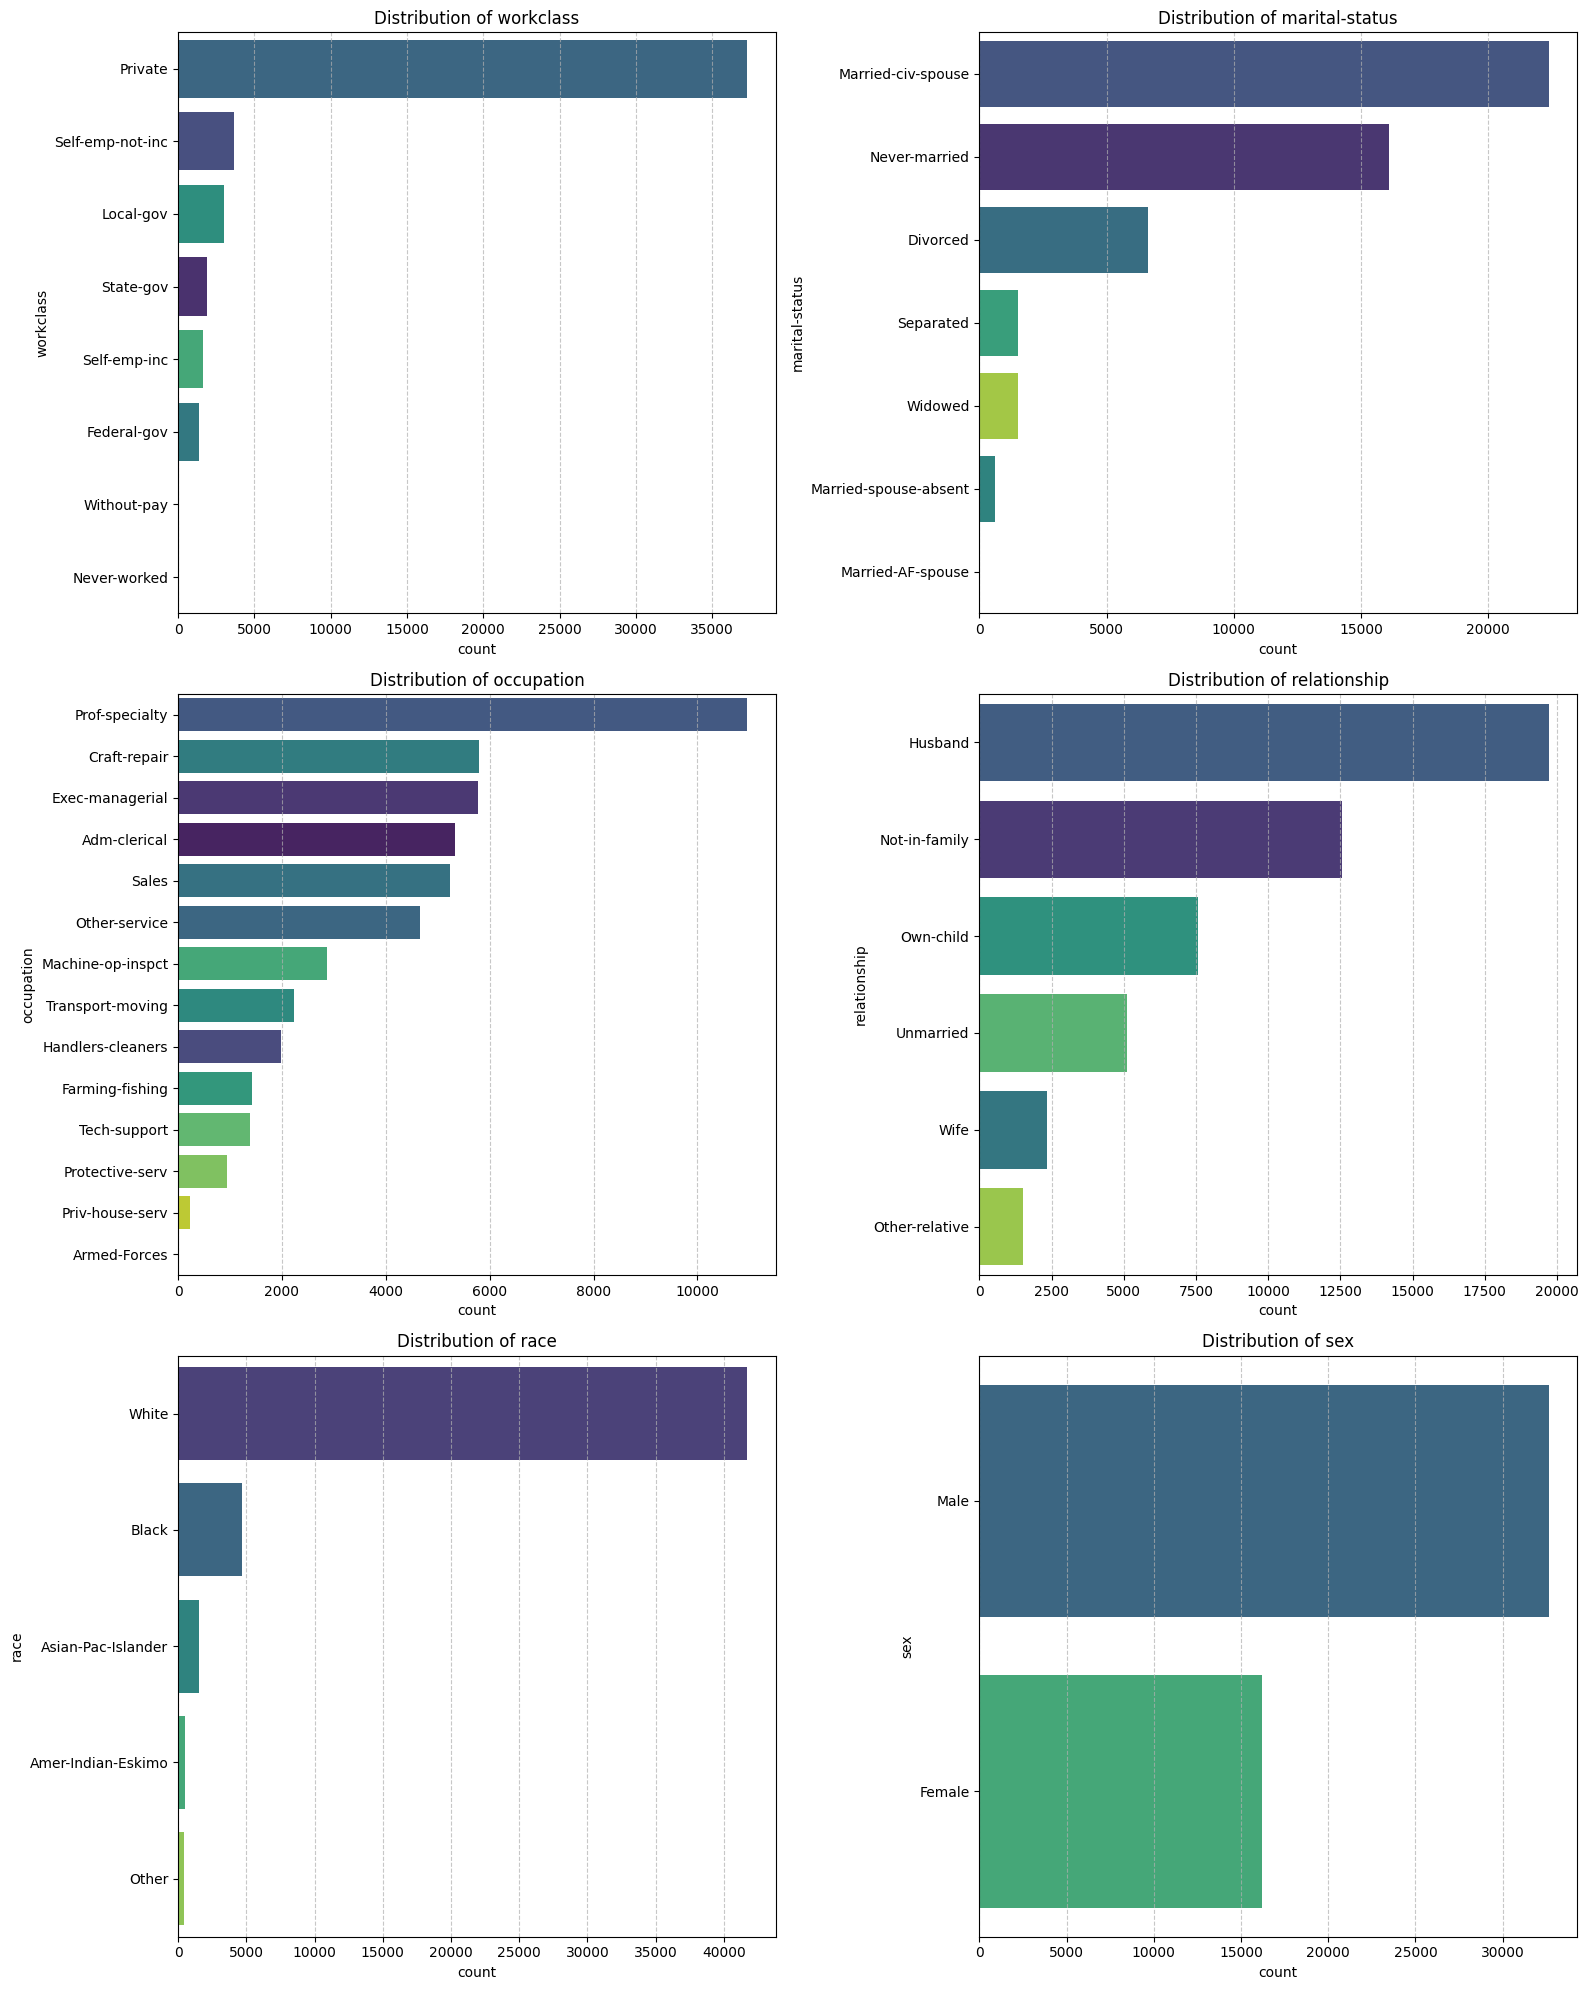

In [98]:
#Visualize Categorical Feature Distributions

# Identify the categorical columns
cat_cols_to_plot = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex']

plt.figure(figsize=(16, 20))
for i, col in enumerate(cat_cols_to_plot, 1):
    plt.subplot(3, 2, i)


    sns.countplot(
        y=data_reduced[col],
        order=data_reduced[col].value_counts().index,
        palette='viridis',
        hue=data_reduced[col],
        legend=False
    )

    plt.title(f'Distribution of {col}')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [99]:
# Excluding income for the time being for encoding
# Saving it separately for later analysis
income_series = data_reduced['income']
data_features = data_reduced.drop(columns=['income'])

#### Encoding

In [100]:
# Using label encoding for binary features like 'sex' keeps the data lean
label_encoder = LabelEncoder()
data_features['sex'] = label_encoder.fit_transform(data_features['sex'])

In [101]:
#ENCODING REMAINING CATEGORIES (One-Hot Encoding)
data_encoded = pd.get_dummies(data_features, drop_first=True, dtype=int)

In [102]:
# to verify if all cat_columns are encoded
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48817 entries, 0 to 48841
Data columns (total 42 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   48817 non-null  float64
 1   education-num                         48817 non-null  float64
 2   sex                                   48817 non-null  int64  
 3   capital-gain                          48817 non-null  int64  
 4   capital-loss                          48817 non-null  int64  
 5   hours-per-week                        48817 non-null  float64
 6   native-country                        48817 non-null  int64  
 7   workclass_Local-gov                   48817 non-null  int64  
 8   workclass_Never-worked                48817 non-null  int64  
 9   workclass_Private                     48817 non-null  int64  
 10  workclass_Self-emp-inc                48817 non-null  int64  
 11  workclass_Self-emp-n

#### Scaling

Although the data was skewed, outliers were handled using IQR. Therefore, StandardScaler was applied to standardize the data for better performance of distance-based clustering algorithms.

In [103]:
#before scaling
data_encoded.describe()

,age,education-num,sex,capital-gain,capital-loss,hours-per-week,native-country,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
count,48817.000000,48817.000000,48817.000000,48817.0,48817.0,48817.000000,48817.000000,48817.000000,48817.000000,48817.000000,...,48817.000000,48817.00000,48817.000000,48817.000000,48817.000000,48817.000000,48817.000000,48817.000000,48817.000000,48817.000000
mean,38.536155,10.122334,0.668476,0.0,0.0,41.130856,0.919024,0.060901,0.000184,0.764508,...,0.045845,0.25739,0.030850,0.155233,0.104984,0.047750,0.031096,0.095971,0.008317,0.854989
std,13.269825,2.456696,0.470766,0.0,0.0,6.033818,0.272801,0.239151,0.013577,0.424310,...,0.209150,0.43720,0.172913,0.362130,0.306536,0.213238,0.173578,0.294554,0.090817,0.352115
min,17.000000,4.500000,0.000000,0.0,0.0,32.500000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,9.000000,0.000000,0.0,0.0,40.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,37.000000,10.000000,1.000000,0.0,0.0,40.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,47.000000,12.000000,1.000000,0.0,0.0,45.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,75.500000,16.000000,1.000000,0.0,0.0,52.500000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [104]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_encoded)

In [105]:
# Convert back to DataFrame to keep it readable (optional but helpful)
data_final = pd.DataFrame(data_scaled, columns=data_encoded.columns)

print("Pre-processing complete. Data is now ready for KMeans.")
print(f"Final feature count: {data_final.shape[1]}")

Pre-processing complete. Data is now ready for KMeans.
Final feature count: 42


In [106]:
#after scaling
data_final.describe()

,age,education-num,sex,capital-gain,capital-loss,hours-per-week,native-country,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
count,4.881700e+04,4.881700e+04,4.881700e+04,48817.0,48817.0,4.881700e+04,4.881700e+04,4.881700e+04,4.881700e+04,4.881700e+04,...,4.881700e+04,4.881700e+04,4.881700e+04,4.881700e+04,4.881700e+04,4.881700e+04,4.881700e+04,4.881700e+04,4.881700e+04,4.881700e+04
mean,2.247328e-16,1.694229e-16,-3.347703e-18,0.0,0.0,-5.526621e-16,9.271682e-17,3.857136e-17,-5.239883e-18,-5.560098e-17,...,8.442034e-18,-2.008622e-17,5.953090e-17,6.724517e-17,7.335837e-17,-6.797293e-17,2.823715e-17,5.996755e-17,1.833959e-17,-1.029055e-16
std,1.000010e+00,1.000010e+00,1.000010e+00,0.0,0.0,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,...,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00
min,-1.622959e+00,-2.288599e+00,-1.419991e+00,0.0,0.0,-1.430428e+00,-3.368880e+00,-2.546573e-01,-1.357925e-02,-1.801786e+00,...,-2.191972e-01,-5.887288e-01,-1.784150e-01,-4.286701e-01,-3.424885e-01,-2.239288e-01,-1.791472e-01,-3.258202e-01,-9.157797e-02,-2.428174e+00
25%,-7.940017e-01,-4.568518e-01,-1.419991e+00,0.0,0.0,-1.874216e-01,2.968345e-01,-2.546573e-01,-1.357925e-02,5.550048e-01,...,-2.191972e-01,-5.887288e-01,-1.784150e-01,-4.286701e-01,-3.424885e-01,-2.239288e-01,-1.791472e-01,-3.258202e-01,-9.157797e-02,4.118320e-01
50%,-1.157642e-01,-4.979683e-02,7.042299e-01,0.0,0.0,-1.874216e-01,2.968345e-01,-2.546573e-01,-1.357925e-02,5.550048e-01,...,-2.191972e-01,-5.887288e-01,-1.784150e-01,-4.286701e-01,-3.424885e-01,-2.239288e-01,-1.791472e-01,-3.258202e-01,-9.157797e-02,4.118320e-01
75%,6.378329e-01,7.643130e-01,7.042299e-01,0.0,0.0,6.412496e-01,2.968345e-01,-2.546573e-01,-1.357925e-02,5.550048e-01,...,-2.191972e-01,1.698575e+00,-1.784150e-01,-4.286701e-01,-3.424885e-01,-2.239288e-01,-1.791472e-01,-3.258202e-01,-9.157797e-02,4.118320e-01
max,2.785585e+00,2.392533e+00,7.042299e-01,0.0,0.0,1.884256e+00,2.968345e-01,3.926845e+00,7.364178e+01,5.550048e-01,...,4.562103e+00,1.698575e+00,5.604909e+00,2.332796e+00,2.919806e+00,4.465704e+00,5.582003e+00,3.069178e+00,1.091966e+01,4.118320e-01


#### PCA

In [107]:
#Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
pca_results = pca.fit_transform(data_final)

#Create a DataFrame for visualization
pca_df = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])



In [108]:
print(pca.explained_variance_ratio_)

[0.07955537 0.05322064]


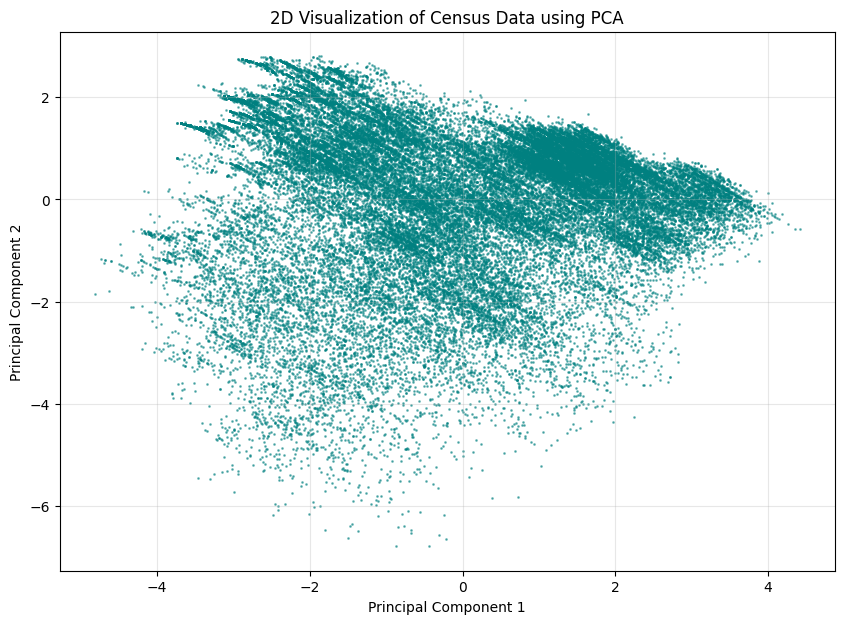

In [109]:
# Plot the PCA components
plt.figure(figsize=(10, 7))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.5, c='teal', s=1)
plt.title('2D Visualization of Census Data using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.3)
plt.show()


#### Inference :
The PCA visualization confirms that the data has a multi-modal structure with distinct branches, justifying the use of K-Means to partition these segments into actionable socioeconomic groups.

### Clustering

In [110]:
# Calculate WCSS for different values of k
wcss = []
k_range = range(2, 8) # Testing from 2 to 7 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(data_final)
    wcss.append(kmeans.inertia_)

#### Plot elbow curve

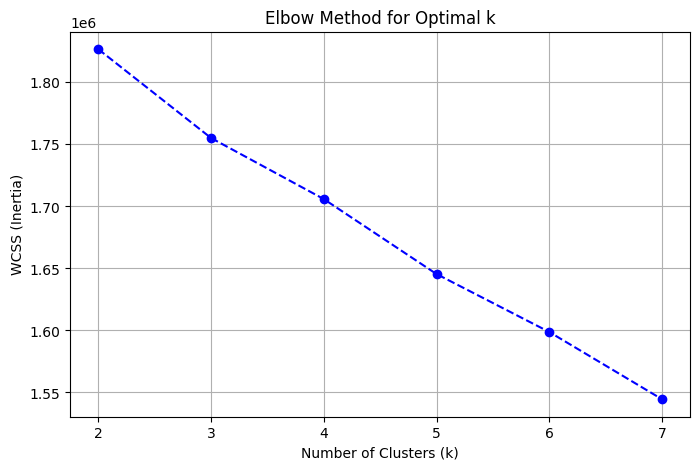

In [111]:
#  Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

#### Silhouette Score Analysis

In [112]:
#  Calculate Silhouette Scores
silhouette_avg = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(data_final)

    # Use a sample for speed and memory efficiency
    sample_indices = np.random.choice(data_final.index, 5000, replace=False)
    score = silhouette_score(data_final.iloc[sample_indices], cluster_labels[sample_indices])
    silhouette_avg.append(score)
    print(f"For k = {k}, the average silhouette_score is : {score:.4f}")


For k = 2, the average silhouette_score is : 0.0852
For k = 3, the average silhouette_score is : 0.0914
For k = 4, the average silhouette_score is : 0.0664
For k = 5, the average silhouette_score is : 0.0995
For k = 6, the average silhouette_score is : 0.0836
For k = 7, the average silhouette_score is : 0.1214


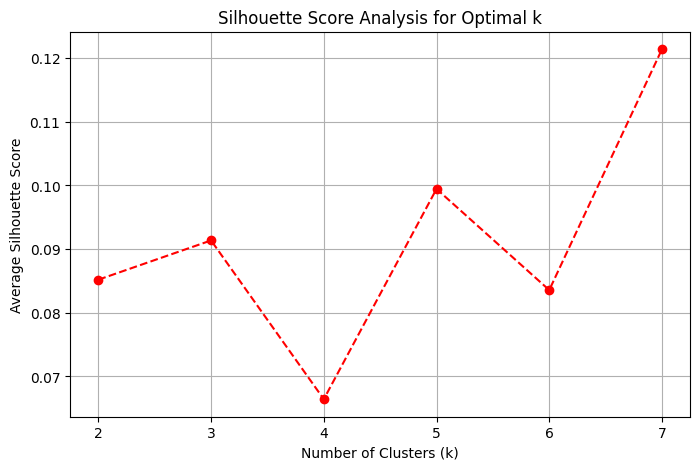

In [113]:
# Plot the Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_avg, marker='o', linestyle='--', color='r')
plt.title('Silhouette Score Analysis for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [114]:
#  Apply K-Means with the optimal k=3
kmeans_final = KMeans(n_clusters=3, n_init=10, random_state=42)
# We store the labels in our 'data_reduced' (the version with original values) for profiling
data_reduced['KMeans_Cluster'] = kmeans_final.fit_predict(data_final)


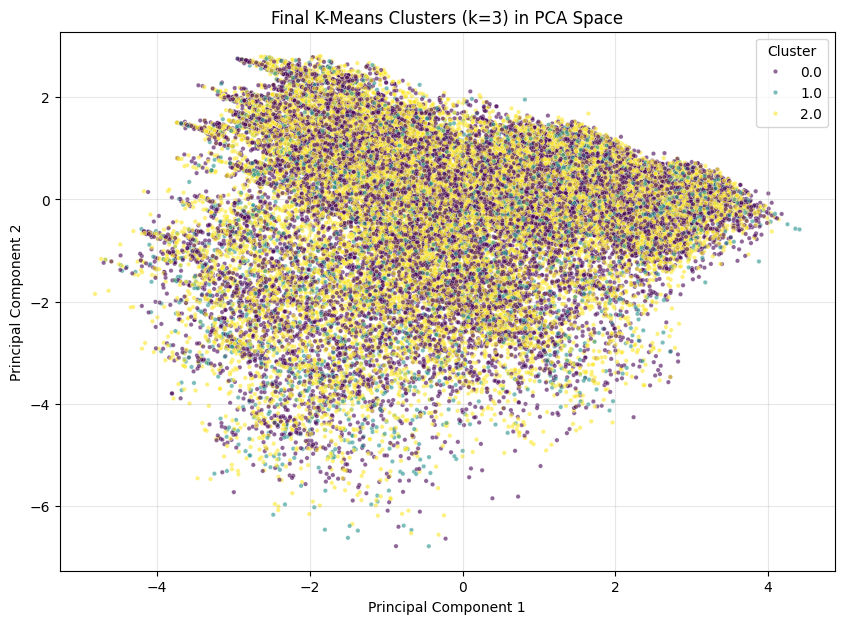

In [115]:
# Visualize the Clusters using PCA
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=pca_df['PC1'],
    y=pca_df['PC2'],
    hue=data_reduced['KMeans_Cluster'],
    palette='viridis',
    alpha=0.6,
    s=10
)
plt.title('Final K-Means Clusters (k=3) in PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

#### Agglomerative Clustering (on a Sample)

In [116]:
# Take a sample for Agglomerative Clustering (Memory efficient)
data_sample = data_final.sample(n=5000, random_state=42)

# Apply Agglomerative Clustering
agg_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg_model.fit_predict(data_sample)


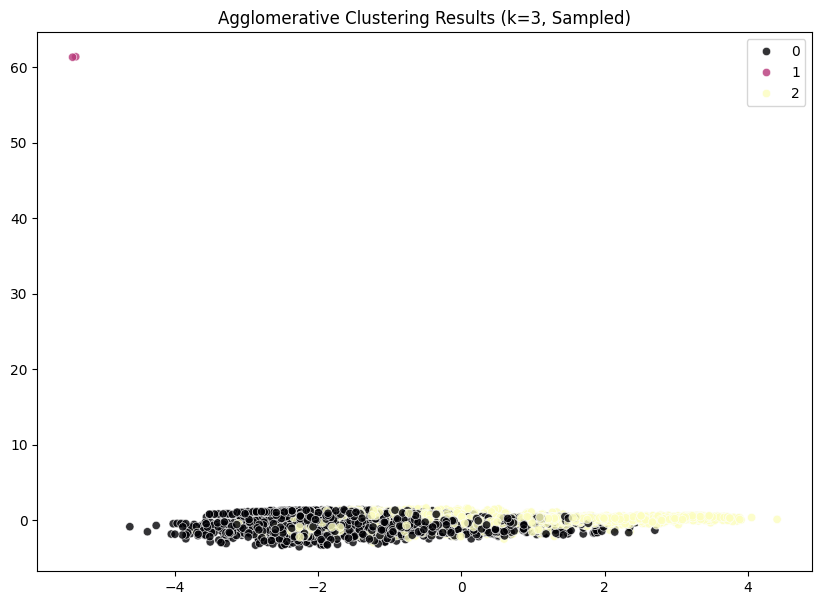

In [117]:
#  Visualize Agglomerative Clusters
# We use PCA on the sample just for this plot
pca_agg = PCA(n_components=2)
pca_agg_results = pca_agg.fit_transform(data_sample)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=pca_agg_results[:, 0], y=pca_agg_results[:, 1], hue=agg_labels, palette='magma', alpha=0.8)
plt.title('Agglomerative Clustering Results (k=3, Sampled)')
plt.show()

### Interpretation and Profiling

In [118]:
# PREPARE PROFILING DATA
# We use 'data_reduced' because it contains the actual numbers (not scaled)
df_profile = data_reduced.copy()
df_profile['Cluster'] = kmeans_final.labels_
# Add back the actual income column from the original 'data' for comparison
df_profile['Income_Level'] = data['income']

In [119]:
#NUMERICAL PROFILING
# Calculate the average values for each group
numeric_stats = df_profile.groupby('Cluster')[['age', 'education-num', 'hours-per-week', 'capital-gain']].mean()
print("--- Average Values per Cluster ---")
print(numeric_stats)


--- Average Values per Cluster ---
               age  education-num  hours-per-week  capital-gain
Cluster                                                        
0        43.235227      10.412501       42.863320           0.0
1        37.843306       9.530448       39.789837           0.0
2        34.193852       9.968907       39.756704           0.0


In [120]:
# INCOME DISTRIBUTION
# See which cluster is actually the "High Earning" group (>50K)
income_dist = pd.crosstab(df_profile['Cluster'], df_profile['Income_Level'], normalize='index') * 100
print("\n--- Income Level Distribution (%) ---")
print(income_dist)



--- Income Level Distribution (%) ---
Income_Level      <=50K       >50K
Cluster                           
0             55.061969  44.938031
1             87.948228  12.051772
2             93.630601   6.369399


In [121]:
#CATEGORICAL ATTRIBUTES
# Find the most common traits (Occupation and Marital Status) for each cluster
for i in range(3):
    print(f"\n--- Identifying Cluster {i} ---")
    top_occ = df_profile[df_profile['Cluster'] == i]['occupation'].mode()[0]
    top_marital = df_profile[df_profile['Cluster'] == i]['marital-status'].mode()[0]
    print(f"Dominant Occupation: {top_occ}")
    print(f"Dominant Marital Status: {top_marital}")


--- Identifying Cluster 0 ---
Dominant Occupation: Prof-specialty
Dominant Marital Status: Married-civ-spouse

--- Identifying Cluster 1 ---
Dominant Occupation: Prof-specialty
Dominant Marital Status: Never-married

--- Identifying Cluster 2 ---
Dominant Occupation: Prof-specialty
Dominant Marital Status: Never-married


## Cluster Interpretation & Policy Recommendations

####Cluster 0: The Established Professionals

Characteristics

*  Average Age: ~43 years (Oldest Group)
*  Education Level: Highest (~10.4 years)
*  Work Hours: Highest (~43 hours/week)
*  Dominant Marital Status: Married-civ-spouse
*  Income Level: High (~45% earn >50K)

Interpretation

This cluster represents the most stable and economically successful segment of the population. They are experienced, highly educated, and likely hold senior roles.

Recommended Policy Actions

Tax Reform: Focus on family-based tax credits and investment/capital gains incentives to encourage wealth management.

Financial Planning: Retirement and pension-related incentives to ensure long-term stability for this aging professional group.

####Cluster 1: The Mid-Career Workforce
Characteristics

*   Average Age: ~38 years
*   Education Level: Lowest (~9.5 years)
*   Work Hours: Standard (~40 hours/week)
*   Dominant Marital Status: Never-married
*  Income Level: Moderate-Low (~12% earn >50K)


Interpretation

This group represents mid-career individuals who may be limited by their lower formal education levels, resulting in lower income despite their experience and age.

Recommended Policy Actions

Upskilling Programs: Targeted vocational training and adult education grants to help bridge the "career ceiling" caused by lower educational attainment.

Social Inclusion: Community-based career counseling and networking resources for single workers.

####Cluster 2: The Emerging Workforce (Young Professionals)
Characteristics

*   Average Age: ~34 years (Youngest Group)
*   Education Level: Moderate-High (~10 years)
*   Work Hours: Standard (~40 hours/week)
*   Dominant Marital Status: Never-married
*   Income Level: Lowest (~6% earn >50K)

Interpretation

This cluster represents the entry-level workforce. While they are relatively well-educated, they have the lowest income, likely due to a lack of seniority and life-stage transitions.

Recommended Policy Actions

Financial Aid: First-time homebuyer assistance and student loan relief programs to support wealth building early in their careers.

Career Entry Support: Subsidies for professional certifications and technical training to accelerate their move into higher income brackets.

## Final Conclusion

The unsupervised learning analysis successfully partitioned the census data into three distinct socioeconomic groups. By utilizing K-Means (validated by Agglomerative Clustering), we uncovered that life-stage (age and marital status) combined with educational attainment are the primary drivers of economic segmentation. These findings allow for highly targeted government interventions, moving away from "one-size-fits-all" policies to more efficient, group-specific support systems.